In [502]:
def border_line(length=64):
    print("=-" * int(length / 2), end="=\n")


open_bold = "\033[1m"
close_bold = "\033[0m"

indentation = "    "

In [503]:
border_line(58)
print("Análise de anúncios de aluguel de imóveis de curta duração.")
border_line(58)
print("\nA base de dados é um CSV de 17 colunas e 12'044 entradas.\n")
print(
    "Os campos textuais em algumas entradas não trataram devidamente as vírgulas, o que separou uma coluna em múltiplas."
)
print("Os dados foram importados no LibreOffice para encontrar essas distorções.\n")
print('Coluna "Nome do anúncio": 8 distorções.')
print(
    'As linhas foram ordenadas pela coluna seguinte, "ID do anunciante". Aquelas com valores textuais ficaram ao final.\n'
)

print('Coluna "Licença": 6 distorções.')
print(
    "Como é a última coluna esperada, qualquer dado que se apresentava após si foi identificado."
)

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
Análise de anúncios de aluguel de imóveis de curta duração.
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

A base de dados é um CSV de 17 colunas e 12'044 entradas.

Os campos textuais em algumas entradas não trataram devidamente as vírgulas, o que separou uma coluna em múltiplas.
Os dados foram importados no LibreOffice para encontrar essas distorções.

Coluna "Nome do anúncio": 8 distorções.
As linhas foram ordenadas pela coluna seguinte, "ID do anunciante". Aquelas com valores textuais ficaram ao final.

Coluna "Licença": 6 distorções.
Como é a última coluna esperada, qualquer dado que se apresentava após si foi identificado.


In [504]:
import textwrap
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def print_numerical_range(
    series: pd.Series,
):
    min_value, max_value = series.min(), series.max()
    if hasattr(min_value, "strftime") and hasattr(max_value, "strftime"):
        min_text = min_value.strftime("%Y-%m-%d")
        max_text = max_value.strftime("%Y-%m-%d")
    else:
        min_text = str(min_value)
        max_text = str(max_value)
    text = f"Intervalo numérico: [{min_text}, {max_text}]"
    print(textwrap.indent(text, indentation))


def column_description(
    name: str,
    series: pd.Series,
    type_description: str,
    description: str,
    column_type: Literal["categorical", "numerical", "date", "other"] = "other",
):
    print(f"{open_bold}{name}{close_bold}")

    empty_amount = series.isnull().sum()
    total_amount = series.count()
    text = f"Identificador: {series.name}\nTipo: {type_description}\n{description}\nVazios: {empty_amount} de {total_amount} ({(empty_amount / total_amount):.2%})"
    print(
        textwrap.indent(
            text,
            indentation,
        )
    )

    if column_type == "categorical":
        values = sorted(series.dropna().unique().tolist())
        text = f"Valores possíveis: {len(values)} {values!s}"
        print(textwrap.indent(text, indentation))

    elif column_type == "date":
        print_numerical_range(series)

    elif column_type == "numerical":
        print_numerical_range(series)
        text = f"Média: {series.mean()}\nMediana: {series.median()}\nDesvio padrão: {series.std()}\nPercentil 05%: {series.quantile(0.05)}\nPercentil 25%: {series.quantile(0.25)}\nPercentil 50%: {series.quantile(0.5)}\nPercentil 75%: {series.quantile(0.75)}\nPercentil 95%: {series.quantile(0.95)}"
        print(textwrap.indent(text, indentation))
        plt.boxplot(series.dropna())
        plt.xlabel("Boxplot")
        plt.ylabel(name)
        plt.show()


In [505]:
def generate_histogram(series: pd.Series, label: str, bins: int | None = None):
    plt.figure(figsize=(10, 5))
    plt.ylabel("Quantidade")
    plt.xlabel(label)
    plt.hist(
        series.dropna(),
        bins=bins,
    )
    plt.show()


def generate_bar_graph(series: pd.Series, label: str):
    counts = series.value_counts()
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(counts))
    ax.bar(x, counts.values)
    ax.set_xticks(x)
    ax.set_xticklabels(
        counts.index,
        rotation=45,
        ha="right",
    )
    ax.set_xlabel(label)
    ax.set_ylabel("Quantidade")
    fig.tight_layout()
    plt.show()


def generate_pie_graph_with_others(
    series: pd.Series,
    label: str,
    top_n: int = 9,
):
    counts = series.value_counts()
    if len(counts) > top_n:
        top = counts.iloc[:top_n]
        others = counts.iloc[top_n:].sum()
        counts = pd.concat(
            [
                top,
                pd.Series({"Outros": others}),
            ]
        )
    _fig, ax = plt.subplots(figsize=(10, 7))
    ax.pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
    )
    ax.set_title(f"Distribuição por {label}")
    plt.tight_layout()
    plt.show()

In [506]:
df = pd.read_csv("data/1_Porto.csv")
df["last_review"] = pd.to_datetime(
    df["last_review"], errors="coerce", format="%Y-%m-%d"
)

In [507]:
from categorical import neighborhoods, neighbourhood_groups, room_types

df.neighbourhood_group = pd.Categorical(
    df.neighbourhood_group,
    categories=neighbourhood_groups,
    ordered=False,
)

df.neighbourhood = pd.Categorical(
    df.neighbourhood,
    categories=neighborhoods,
    ordered=False,
)

df.room_type = pd.Categorical(
    df.room_type,
    categories=room_types,
    ordered=False,
)

=-=-=-=
Colunas
=-=-=-=

ID do anúncio
    Identificador: id
    Tipo: Textual (sequência de dígitos)
    Identificador interno dado pelo Airbnb para esta entrada.
    Vazios: 0 de 12044 (0.00%)

Nome do anúncio
    Identificador: name
    Tipo: Textual
    Nome dado pelos anunciantes a este anúncio.
    Vazios: 0 de 12044 (0.00%)

ID do anunciante
    Identificador: host_id
    Tipo: Textual (sequência de dígitos)
    Identificador interno dado pelo Airbnb para a conta do anunciante que registrou esta entrada.
    Vazios: 0 de 12044 (0.00%)

Nome do anunciante
    Identificador: host_name
    Tipo: Textual
    Nome do anunciante que registrou esta entrada. Mesmo quando há mais de uma pessoa, eles são responsáveis pela mesma conta no Airbnb.
    Vazios: 0 de 12044 (0.00%)

Município do imóvel
    Identificador: neighbourhood_group
    Tipo: Categórico, não ordenado
    Município em que o imóvel anunciado está localizado. Obtido por meio da localização geográfica.
    Vazios: 0 de 12044

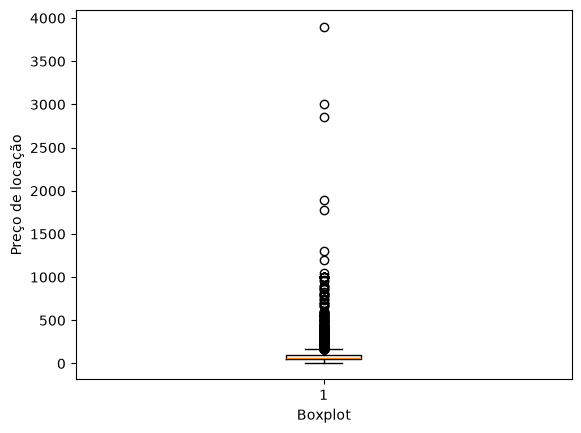

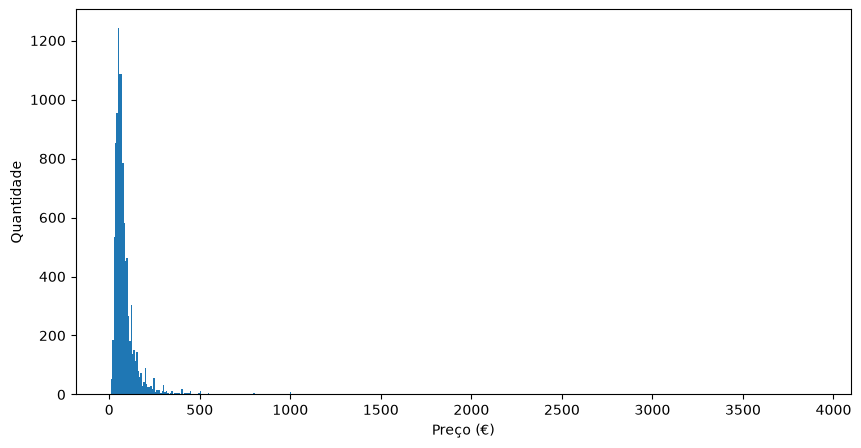

Estadia mínima
    Identificador: minimum_nights
    Tipo: Inteiro
    Quantidade mínima de dias que o hóspede deve contratar de estadia.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [1, 1125]
    Média: 4.0848555297243445
    Mediana: 2.0
    Desvio padrão: 34.046935670996234
    Percentil 05%: 1.0
    Percentil 25%: 1.0
    Percentil 50%: 2.0
    Percentil 75%: 2.0
    Percentil 95%: 5.0


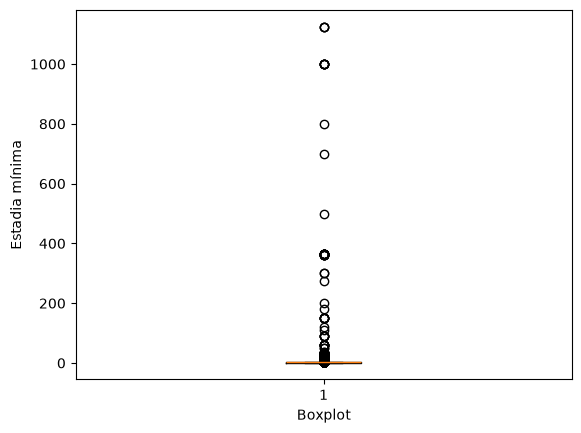

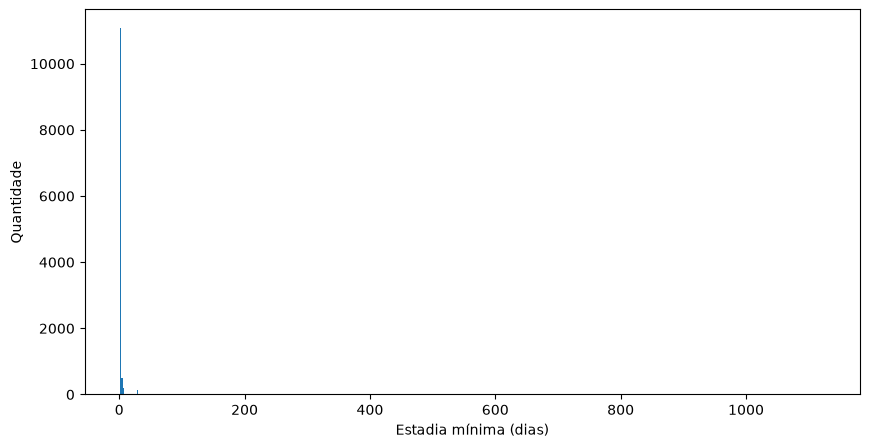

Quantidade de avaliações
    Identificador: number_of_reviews
    Tipo: Inteiro
    Quantidade de avaliações que este anúncio recebeu por meio da plataforma Airbnb.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [0, 976]
    Média: 76.43839256061109
    Mediana: 36.0
    Desvio padrão: 103.78154024166896
    Percentil 05%: 0.0
    Percentil 25%: 7.0
    Percentil 50%: 36.0
    Percentil 75%: 105.0
    Percentil 95%: 286.85000000000036


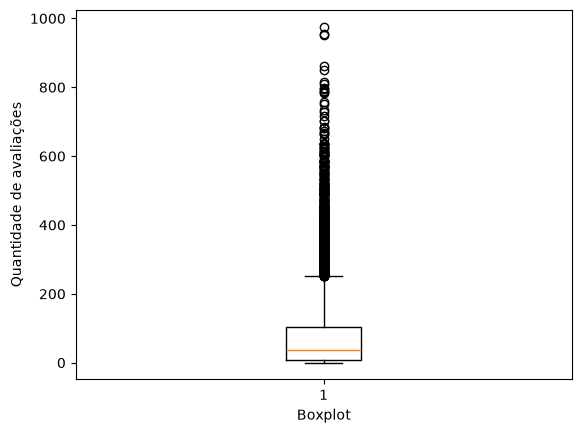

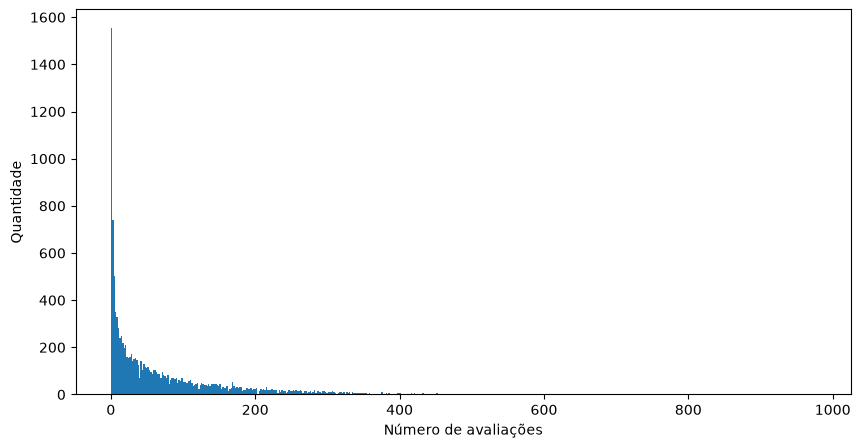

Data da última avaliação
    Identificador: last_review
    Tipo: Data (dia, mês, e ano)
    Data em que a avaliação mais recente deste anúncio foi realizada por meio da plataforma Airbnb.
    Vazios: 1073 de 10971 (9.78%)
    Intervalo numérico: [2013-01-02, 2024-12-14]

Média de avaliações por mês
    Identificador: reviews_per_month
    Tipo: Inteiro
    Quantidade média de avaliações que este anúncio recebeu por mês por meio da plataforma Airbnb.
    Vazios: 1073 de 10971 (9.78%)
    Intervalo numérico: [0.01, 16.43]
    Média: 1.616888159693738
    Mediana: 1.09
    Desvio padrão: 1.5990049823613444
    Percentil 05%: 0.05
    Percentil 25%: 0.33
    Percentil 50%: 1.09
    Percentil 75%: 2.48
    Percentil 95%: 4.89


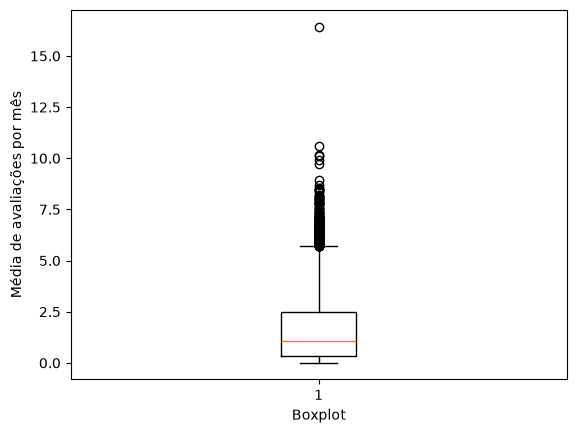

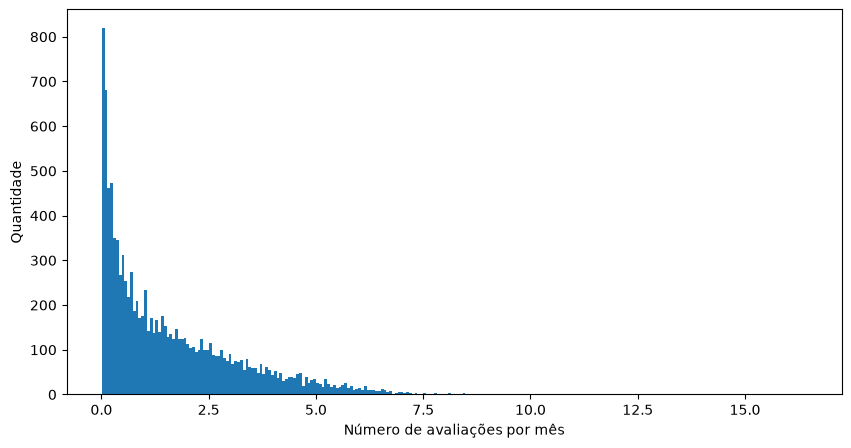

Quantidade de anúncios do anunciante
    Identificador: calculated_host_listings_count
    Tipo: Inteiro
    Quantidade de anúncios que este anunciante realizou na grande região de escopo deste dataset.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [1, 334]
    Média: 18.3867485885088
    Mediana: 5.0
    Desvio padrão: 43.29776416538993
    Percentil 05%: 1.0
    Percentil 25%: 2.0
    Percentil 50%: 5.0
    Percentil 75%: 13.0
    Percentil 95%: 92.0


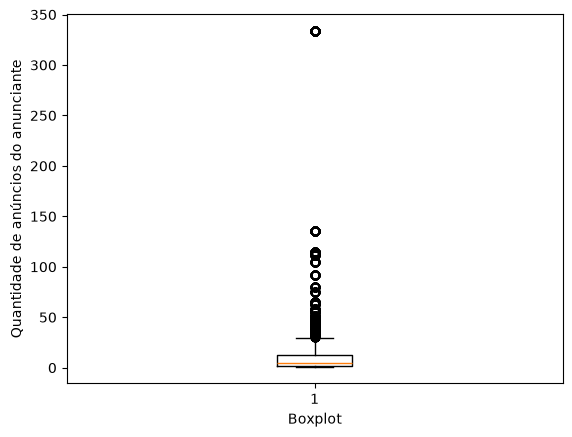

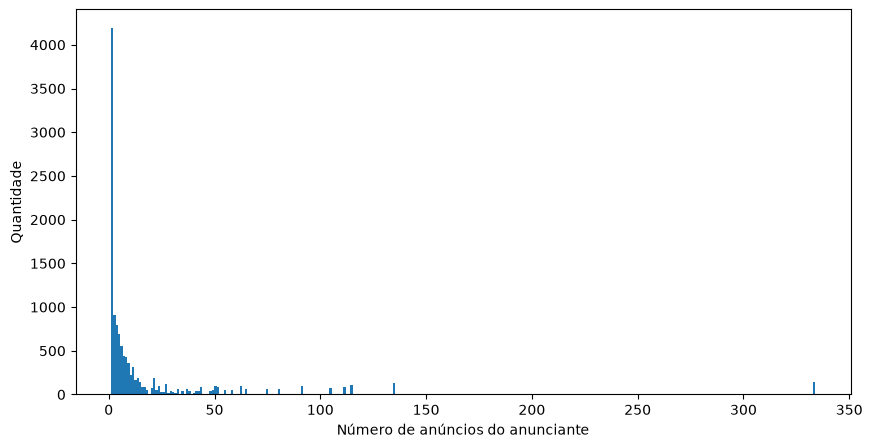

Quantidade de dias disponíveis
    Identificador: availability_365
    Tipo: Inteiro
    Quantidade de dias nos próximos 365 dias em que este anúncio estará disponível para locação.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [0, 365]
    Média: 234.66722019262704
    Mediana: 286.0
    Desvio padrão: 129.32772094698745
    Percentil 05%: 0.0
    Percentil 25%: 137.0
    Percentil 50%: 286.0
    Percentil 75%: 346.0
    Percentil 95%: 364.0


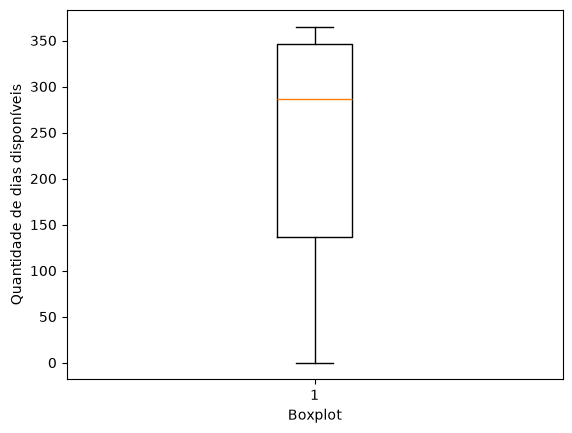

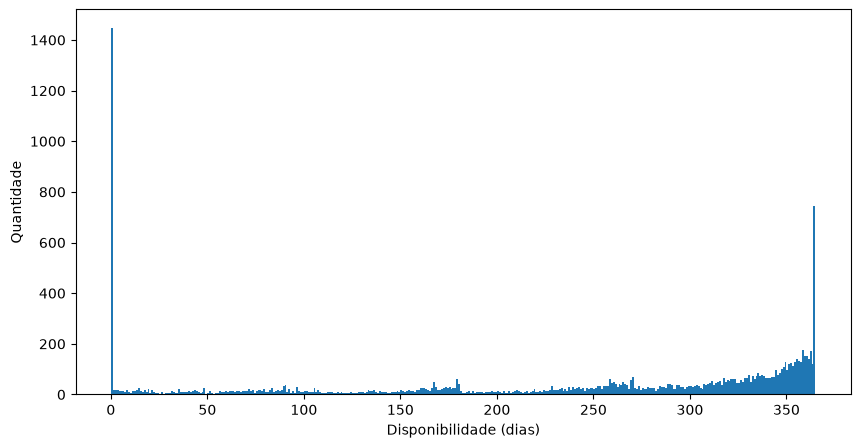

Licença
    Identificador: license
    Tipo: Textual
    Licença de Alojamento Local (AL) obtida para operar a locação do imóvel deste anúncio.
    Vazios: 670 de 11374 (5.89%)



In [508]:
border_line(6)
print("Colunas")
border_line(6)
print()

column_description(
    name="ID do anúncio",
    series=df.id,
    type_description="Textual (sequência de dígitos)",
    description="Identificador interno dado pelo Airbnb para esta entrada.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="Nome do anúncio",
    series=df.name,
    type_description="Textual",
    description="Nome dado pelos anunciantes a este anúncio.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="ID do anunciante",
    series=df.host_id,
    type_description="Textual (sequência de dígitos)",
    description="Identificador interno dado pelo Airbnb para a conta do anunciante que registrou esta entrada.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="Nome do anunciante",
    series=df.host_name,
    type_description="Textual",
    description="Nome do anunciante que registrou esta entrada. Mesmo quando há mais de uma pessoa, eles são responsáveis pela mesma conta no Airbnb.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="Município do imóvel",
    series=df.neighbourhood_group,
    type_description="Categórico, não ordenado",
    description="Município em que o imóvel anunciado está localizado. Obtido por meio da localização geográfica.",
    column_type="categorical",
)
# Quais municípios serão mais baratos?
print()

column_description(
    name="Freguesia do imóvel",
    series=df.neighbourhood,
    type_description="Categórico, não ordenado",
    description="Freguesia em que o imóvel anunciado está localizado. Está dentro de apenas um município.",
    column_type="categorical",
)
# Quais freguesias serão mais baratas?
print()

column_description(
    name="Latitude do imóvel",
    series=df.latitude,
    type_description="Real",
    description="Latitude da localização do imóvel anunciado conforme o World Geodetic System (WGS84).",
    column_type="other",
)
# Creio ser menos relevante do que a freguesia calculada.
print()

column_description(
    name="Longitude do imóvel",
    series=df.longitude,
    type_description="Real",
    description="Longitude da localização do imóvel anunciado conforme o World Geodetic System (WGS84).",
    column_type="other",
)
# Creio ser menos relevante do que a freguesia calculada.
print()

column_description(
    name="Tipo de locação",
    series=df.room_type,
    type_description="Categórico, não ordenado",
    description="Tipo da locação sendo anunciada. Especifica quais áreas do imóvel o inquilino poderá acessar.",
    column_type="categorical",
)
# Um imóvel menor (quarto) será mais barato?
print()

column_description(
    name="Preço de locação",
    series=df.price,
    type_description="Real",
    description="Preço diário de locação deste anúncio em euros.",
    column_type="numerical",
)
print()
generate_histogram(series=df.price, label="Preço (€)", bins=500)

column_description(
    name="Estadia mínima",
    series=df.minimum_nights,
    type_description="Inteiro",
    description="Quantidade mínima de dias que o hóspede deve contratar de estadia.",
    column_type="numerical",
)
# Um anúncio com estadia longa será mais barato?
print()
generate_histogram(series=df.minimum_nights, label="Estadia mínima (dias)", bins=500)

column_description(
    name="Quantidade de avaliações",
    series=df.number_of_reviews,
    type_description="Inteiro",
    description="Quantidade de avaliações que este anúncio recebeu por meio da plataforma Airbnb.",
    column_type="numerical",
)
# Um anúncio muito avaliado será mais barato?
print()
generate_histogram(series=df.number_of_reviews, label="Número de avaliações", bins=500)

column_description(
    name="Data da última avaliação",
    series=df.last_review,
    type_description="Data (dia, mês, e ano)",
    description="Data em que a avaliação mais recente deste anúncio foi realizada por meio da plataforma Airbnb.",
    column_type="date",
)
# Creio não ter muita relevância.
print()

column_description(
    name="Média de avaliações por mês",
    series=df.reviews_per_month,
    type_description="Inteiro",
    description="Quantidade média de avaliações que este anúncio recebeu por mês por meio da plataforma Airbnb.",
    column_type="numerical",
)
# Um anúncio com muitas avaliações será mais barato?
print()
generate_histogram(
    series=df.reviews_per_month,
    label="Número de avaliações por mês",
    bins=250,
)

column_description(
    name="Quantidade de anúncios do anunciante",
    series=df.calculated_host_listings_count,
    type_description="Inteiro",
    description="Quantidade de anúncios que este anunciante realizou na grande região de escopo deste dataset.",
    column_type="numerical",
)
# Um anunciante que publica muitos anúncios será mais barato?
print()
generate_histogram(
    series=df.calculated_host_listings_count,
    label="Número de anúncios do anunciante",
    bins=300,
)

column_description(
    name="Quantidade de dias disponíveis",
    series=df.availability_365,
    type_description="Inteiro",
    description="Quantidade de dias nos próximos 365 dias em que este anúncio estará disponível para locação.",
    column_type="numerical",
)
# Um imóvel com disponibilidade alta será mais barato?
print()
generate_histogram(
    series=df.availability_365,
    label="Disponibilidade (dias)",
    bins=365,
)

column_description(
    name="Licença",
    series=df.license,
    type_description="Textual",
    description="Licença de Alojamento Local (AL) obtida para operar a locação do imóvel deste anúncio.",
    column_type="other",
)
# Um imóvel sem licença registrada ou isento de licença será mais barato?
print()

In [509]:
def describe_columns(
    data_frame=pd.DataFrame,
    bins=(
        100,
        3,
        100,
        100,
        35,
        365,
    ),
):
    border_line(6)
    print("Colunas")
    border_line(6)
    print()

    column_description(
        name="Município do imóvel",
        series=data_frame.neighbourhood_group,
        type_description="Categórico, não ordenado",
        description="Município em que o imóvel anunciado está localizado. Obtido por meio da localização geográfica.",
        column_type="categorical",
    )
    # Quais municípios serão mais baratos?
    print()
    generate_bar_graph(
        series=data_frame.neighbourhood_group,
        label="Município do imóvel",
    )

    column_description(
        name="Freguesia do imóvel",
        series=data_frame.neighbourhood,
        type_description="Categórico, não ordenado",
        description="Freguesia em que o imóvel anunciado está localizado. Está dentro de apenas um município.",
        column_type="categorical",
    )
    # Quais freguesias serão mais baratas?
    print()
    generate_pie_graph_with_others(
        series=data_frame.neighbourhood, label="Freguesia do imóvel"
    )

    column_description(
        name="Tipo de locação",
        series=data_frame.room_type,
        type_description="Categórico, não ordenado",
        description="Tipo da locação sendo anunciada. Especifica quais áreas do imóvel o inquilino poderá acessar.",
        column_type="categorical",
    )
    # Um imóvel menor (quarto) será mais barato?
    print()
    generate_bar_graph(series=data_frame.room_type, label="Tipo de locação")

    column_description(
        name="Preço de locação",
        series=data_frame.price,
        type_description="Real",
        description="Preço diário de locação deste anúncio em euros.",
        column_type="numerical",
    )
    print()
    generate_histogram(series=data_frame.price, label="Preço (€)", bins=bins[0])

    column_description(
        name="Estadia mínima",
        series=data_frame.minimum_nights,
        type_description="Inteiro",
        description="Quantidade mínima de dias que o hóspede deve contratar de estadia.",
        column_type="numerical",
    )
    # Um anúncio com estadia longa será mais barato?
    print()
    generate_histogram(
        series=data_frame.minimum_nights, label="Estadia mínima (dias)", bins=bins[1]
    )

    column_description(
        name="Quantidade de avaliações",
        series=data_frame.number_of_reviews,
        type_description="Inteiro",
        description="Quantidade de avaliações que este anúncio recebeu por meio da plataforma Airbnb.",
        column_type="numerical",
    )
    # Um anúncio muito avaliado será mais barato?
    print()
    generate_histogram(
        series=data_frame.number_of_reviews, label="Número de avaliações", bins=bins[2]
    )

    column_description(
        name="Data da última avaliação",
        series=data_frame.last_review,
        type_description="Categórico, não ordenado",
        description="Data em que a avaliação mais recente deste anúncio foi realizada por meio da plataforma Airbnb.",
        column_type="categorical",
    )
    # Creio não ter muita relevância.
    print()
    generate_bar_graph(series=data_frame.last_review, label="Data da última avaliação")

    column_description(
        name="Média de avaliações por mês",
        series=data_frame.reviews_per_month,
        type_description="Inteiro",
        description="Quantidade média de avaliações que este anúncio recebeu por mês por meio da plataforma Airbnb.",
        column_type="numerical",
    )
    # Um anúncio com muitas avaliações será mais barato?
    print()
    generate_histogram(
        series=data_frame.reviews_per_month,
        label="Número de avaliações por mês",
        bins=bins[3],
    )

    column_description(
        name="Quantidade de anúncios do anunciante",
        series=data_frame.calculated_host_listings_count,
        type_description="Inteiro",
        description="Quantidade de anúncios que este anunciante realizou na grande região de escopo deste dataset.",
        column_type="numerical",
    )
    # Um anunciante que publica muitos anúncios será mais barato?
    print()
    generate_histogram(
        series=data_frame.calculated_host_listings_count,
        label="Número de anúncios do anunciante",
        bins=bins[4],
    )

    column_description(
        name="Quantidade de dias disponíveis",
        series=data_frame.availability_365,
        type_description="Inteiro",
        description="Quantidade de dias nos próximos 365 dias em que este anúncio estará disponível para locação.",
        column_type="numerical",
    )
    # Um imóvel com disponibilidade alta será mais barato?
    print()
    generate_histogram(
        series=data_frame.availability_365, label="Disponibilidade (dias)", bins=bins[5]
    )

    column_description(
        name="Licença",
        series=data_frame.license,
        type_description="Categórico, não ordenado",
        description="Licença de Alojamento Local (AL) obtida para operar a locação do imóvel deste anúncio.",
        column_type="categorical",
    )
    # Um imóvel sem licença registrada ou isento de licença será mais barato?
    print()


In [510]:
total_amount_before_treatment = df.id.size

print(f"{open_bold}Remoção de entradas sem atributo de interesse{close_bold}")

empty_amount_of_price = df.price.isna().sum()
not_empty_amount_of_price = total_amount_before_treatment - empty_amount_of_price
print(
    f"""O objetivo do modelo é estimar o {open_bold}preço de hospedagem por dia{close_bold} (em euros).
Logo, não faz sentido completar os dados faltantes na coluna {open_bold}price{close_bold}.
Assim, as {empty_amount_of_price} entradas vazias foram eliminadas, restando {open_bold}{not_empty_amount_of_price}{close_bold} entradas ({(empty_amount_of_price / total_amount_before_treatment):.2%} / {(not_empty_amount_of_price / total_amount_before_treatment):.2%}).""",
)
df2 = df.dropna(subset=["price"])


Remoção de entradas sem atributo de interesse
O objetivo do modelo é estimar o preço de hospedagem por dia (em euros).
Logo, não faz sentido completar os dados faltantes na coluna price.
Assim, as 1593 entradas vazias foram eliminadas, restando 10451 entradas (13.23% / 86.77%).


In [511]:
print(f"{open_bold}Remoção de duplicatas{close_bold}")

print("São consideradas entradas duplicadas aquelas:")
print(
    textwrap.indent(
        'que compartilham Nome, ID do anunciante, Licença;\ne que sejam de tipo "Entire home/apt",\npois quartos individuais podem ser anúncios separados de um mesmo apartamento ou casa.',
        indentation,
    )
)
print(
    f"\nPara as duplicatas, será mantida a que tenha a maior quantidade de {open_bold}colunas preenchidas{close_bold}.\nEm caso de empate, considerar-se-á aquela com maior quantidade de {open_bold}avaliações{close_bold}.\n"
)


def print_statistics_about_removal(total_amount: int, remaining_amount: int):
    removed_amount = total_amount - remaining_amount
    print(
        f"Eliminadas {total_amount - remaining_amount} entradas de {total_amount} ({(removed_amount / total_amount):.2%} / {(remaining_amount / total_amount):.2%})."
    )


total_amount = df2.id.size

entire_home_mask = df2["room_type"].eq("Entire home/apt")
has_license_mask = df2["license"].notna()
duplicated_mask = (
    entire_home_mask
    & has_license_mask
    & df2.duplicated(subset=["host_id", "name", "license"], keep=False)
)

df2[duplicated_mask].sort_values(["host_id", "name", "license"])

df_selected = df2[duplicated_mask].copy()
df_not_selected = df2[~duplicated_mask].copy()

df_selected["filled_columns"] = df_selected.notna().sum(axis=1)
df_selected = df_selected.sort_values(
    ["host_id", "name", "license", "filled_columns", "number_of_reviews"],
    ascending=[True, True, True, False, False],
).drop_duplicates(subset=["host_id", "name", "license"], keep="first")

df3 = pd.concat([df_not_selected, df_selected], ignore_index=True)
df3 = df3.drop(columns="filled_columns")

remaining_amount = df3.id.size
print_statistics_about_removal(
    total_amount=total_amount, remaining_amount=remaining_amount
)
print()

print(f"{open_bold}Total inicial{close_bold}.", end=" ")
print_statistics_about_removal(
    total_amount=total_amount_before_treatment, remaining_amount=remaining_amount
)


Remoção de duplicatas
São consideradas entradas duplicadas aquelas:
    que compartilham Nome, ID do anunciante, Licença;
    e que sejam de tipo "Entire home/apt",
    pois quartos individuais podem ser anúncios separados de um mesmo apartamento ou casa.

Para as duplicatas, será mantida a que tenha a maior quantidade de colunas preenchidas.
Em caso de empate, considerar-se-á aquela com maior quantidade de avaliações.

Eliminadas 46 entradas de 10451 (0.44% / 99.56%).

Total inicial. Eliminadas 1639 entradas de 12044 (13.61% / 86.39%).


In [512]:
print(f"{open_bold}Detecção de outliers{close_bold}")

print(
    f"Para os atributos numéricos, usamos o {open_bold}Intervalo Interquartil (IQR){close_bold}.\nAs entradas com valores fora do intervalo foram substituídas pelos limites calculados.\n"
)


def print_statistics_about_modifying(total_amount: int, modified_amount: int):
    not_modified_amount = total_amount - modified_amount
    print(
        f"Modificadas {modified_amount} entradas de {total_amount} ({(modified_amount / total_amount):.2%} / {(not_modified_amount / total_amount):.2%})."
    )


def treat_outliers_through_iqr(
    data_frame: pd.DataFrame,
    column_name: str,
    attribute_name: str,
):
    first_quartile = data_frame[column_name].quantile(0.25)
    third_quartile = data_frame[column_name].quantile(0.75)
    iqr = third_quartile - first_quartile
    lower = first_quartile - 1.5 * iqr
    upper = third_quartile + 1.5 * iqr
    outliers = (data_frame[column_name] < lower) | (data_frame[column_name] > upper)
    outliers_amount = outliers.sum()
    data_frame[column_name] = data_frame[column_name].clip(
        lower=lower,
        upper=upper,
    )
    print(f"Atributo: {open_bold}{attribute_name}{close_bold}.", end=" ")
    print_statistics_about_modifying(
        total_amount=total_amount, modified_amount=outliers_amount
    )
    return data_frame


df4 = df3.copy()

df4 = treat_outliers_through_iqr(
    data_frame=df4, column_name="price", attribute_name="Preço de locação"
)
df4 = treat_outliers_through_iqr(
    data_frame=df4, column_name="minimum_nights", attribute_name="Estadia mínima"
)
df4 = treat_outliers_through_iqr(
    data_frame=df4,
    column_name="number_of_reviews",
    attribute_name="Quantidade de avaliações",
)
df4 = treat_outliers_through_iqr(
    data_frame=df4,
    column_name="reviews_per_month",
    attribute_name="Média de avaliações por mês",
)
df4 = treat_outliers_through_iqr(
    data_frame=df4,
    column_name="calculated_host_listings_count",
    attribute_name="Quantidade de anúncios do anunciante",
)
print()


Detecção de outliers
Para os atributos numéricos, usamos o Intervalo Interquartil (IQR).
As entradas com valores fora do intervalo foram substituídas pelos limites calculados.

Atributo: Preço de locação. Modificadas 784 entradas de 10451 (7.50% / 92.50%).
Atributo: Estadia mínima. Modificadas 722 entradas de 10451 (6.91% / 93.09%).
Atributo: Quantidade de avaliações. Modificadas 636 entradas de 10451 (6.09% / 93.91%).
Atributo: Média de avaliações por mês. Modificadas 188 entradas de 10451 (1.80% / 98.20%).
Atributo: Quantidade de anúncios do anunciante. Modificadas 1552 entradas de 10451 (14.85% / 85.15%).



In [513]:
print(f"{open_bold}Preenchimento de valores faltantes{close_bold}\n")

df5 = df4.copy()

print(
    f"Atributo: {open_bold}Média de avaliações por mês{close_bold}.\n{indentation}Todas as entradas faltantes são de anúncios sem avaliações. Basta substituir por {open_bold}0{close_bold}."
)
print(indentation, end="")
print_statistics_about_modifying(
    total_amount=total_amount, modified_amount=df.reviews_per_month.isna().sum()
)
df5["reviews_per_month"] = df5["reviews_per_month"].fillna(0)


Preenchimento de valores faltantes

Atributo: Média de avaliações por mês.
    Todas as entradas faltantes são de anúncios sem avaliações. Basta substituir por 0.
    Modificadas 1073 entradas de 10451 (10.27% / 89.73%).


In [514]:
print(f"{open_bold}Transformação de atributos diversos em categóricos{close_bold}\n")

df6 = df5.copy()

print(f"Atributo: {open_bold}Data da última avaliação{close_bold}.")
print(
    textwrap.indent(
        f'Podem ser substituídas apenas pelo {open_bold}ano{close_bold} (2013 - 2024).\nAquelas não preenchidas entram em uma categoria "no_reviews".',
        indentation,
    )
)
df6["last_review"] = (
    df6["last_review"]
    .dt.year.astype("Int64")
    .astype("string")
    .fillna("no_reviews")
    .astype("category")
)

print(f"\nAtributo: {open_bold}Licença{close_bold}.")
print(
    textwrap.indent(
        f'Podem ser substituídas pelo {open_bold}tipo de licença{close_bold}.\n"no_license", "al", "ter", "exempt" e "others".',
        indentation,
    )
)

license = df6["license"].astype("string").str.strip()
df6["license"] = np.select(
    [
        license.isna() | license.eq(""),
        # AL:
        # - contains AL
        # - or it has only numbers
        license.str.contains(r"\bAL\b", case=False, na=False)
        | license.str.fullmatch(r"\d+", na=False),
        # TER:
        # - contains TER, RNET, RNT or rural
        license.str.contains(
            r"TER|RNET|RNT|rural",
            case=False,
            na=False,
        ),
        # Exempt
        license.str.fullmatch(
            r"exempt",
            case=False,
            na=False,
        ),
    ],
    [
        "no_license",
        "al",
        "ter",
        "exempt",
    ],
    default="others",
)
df6["license"] = df6["license"].astype("category")


Transformação de atributos diversos em categóricos

Atributo: Data da última avaliação.
    Podem ser substituídas apenas pelo ano (2013 - 2024).
    Aquelas não preenchidas entram em uma categoria "no_reviews".

Atributo: Licença.
    Podem ser substituídas pelo tipo de licença.
    "no_license", "al", "ter", "exempt" e "others".


In [515]:
print(f"{open_bold}Remoção de características irrelevantes{close_bold}\n")

df7 = df6.copy()

print(
    f"Atributo: {open_bold}ID do anúncio{close_bold}.\n{indentation}É único para cada entrada, e não confere relevância estatística.\n"
)
df7 = df7.drop(columns=["id"])

print(
    f"Atributo: {open_bold}Nome do anúncio{close_bold}.\n{indentation}Poderia ser interessante extrair características por PLN, mas está fora do escopo deste tratamento.\n"
)
df7 = df7.drop(columns=["name"])

print(
    f'Atributo: {open_bold}ID do anunciante{close_bold}.\n{indentation}Informações acerca do anunciante já são representadas pelo atributo "Quantidade de anúncios do anunciante".\n'
)
df7 = df7.drop(columns=["host_id"])

print(
    f"Atributo: {open_bold}Nome do anunciante{close_bold}.\n{indentation}Não tem relevância estatística.\n"
)
df7 = df7.drop(columns=["host_name"])

print(
    f"Atributo: {open_bold}Latitude do imóvel{close_bold}.\n{indentation}É usado para identificar a freguesia e o município. Não tem relevância além disso\n"
)
df7 = df7.drop(columns=["latitude"])

print(
    f"Atributo: {open_bold}Longitude do imóvel{close_bold}.\n{indentation}É usado para identificar a freguesia e o município. Não tem relevância além disso\n"
)
df7 = df7.drop(columns=["longitude"])

Remoção de características irrelevantes

Atributo: ID do anúncio.
    É único para cada entrada, e não confere relevância estatística.

Atributo: Nome do anúncio.
    Poderia ser interessante extrair características por PLN, mas está fora do escopo deste tratamento.

Atributo: ID do anunciante.
    Informações acerca do anunciante já são representadas pelo atributo "Quantidade de anúncios do anunciante".

Atributo: Nome do anunciante.
    Não tem relevância estatística.

Atributo: Latitude do imóvel.
    É usado para identificar a freguesia e o município. Não tem relevância além disso

Atributo: Longitude do imóvel.
    É usado para identificar a freguesia e o município. Não tem relevância além disso



In [516]:
from sklearn import preprocessing

print(f"{open_bold}Padronização de variáveis numéricas{close_bold}\n")

print(
    f"Os outliers já foram tratados.\nPadronizaremos os valores numéricos pelo {open_bold}StandardScaler{close_bold}, para que tenham média 0 e desvio padrão 1."
)

df8 = df7.copy()

numeric_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]
df8[numeric_columns] = df8[numeric_columns].astype("float64")

scaler = preprocessing.StandardScaler()
df8[numeric_columns] = scaler.fit_transform(df8[numeric_columns])

print(f"\n{open_bold}Média{close_bold}")
print(df8[numeric_columns].mean())

print(f"\n{open_bold}Desvio padrão{close_bold}")
print(df8[numeric_columns].std())

df8

Padronização de variáveis numéricas

Os outliers já foram tratados.
Padronizaremos os valores numéricos pelo StandardScaler, para que tenham média 0 e desvio padrão 1.

Média
price                            -6.009396e-17
minimum_nights                   -3.277852e-17
number_of_reviews                -6.555704e-17
reviews_per_month                 3.824161e-17
calculated_host_listings_count   -3.277852e-17
availability_365                  3.277852e-17
dtype: float64

Desvio padrão
price                             1.000048
minimum_nights                    1.000048
number_of_reviews                 1.000048
reviews_per_month                 1.000048
calculated_host_listings_count    1.000048
availability_365                  1.000048
dtype: float64


,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,license
0,PORTO,Bonfim,Entire home/apt,0.603717,1.369208,2.055971,2024,0.008277,-0.556297,0.653755,al
1,PORTO,"Cedofeita, Ildefonso, Sé, Miragaia, Nicolau, V...",Entire home/apt,-0.210717,1.369208,2.412417,2024,0.141678,-0.808806,0.578635,al
2,VILA NOVA DE GAIA,Canidelo,Entire home/apt,2.270761,-1.095816,-0.783721,2023,-0.957287,-0.808806,0.954233,others
3,PORTO,Bonfim,Entire home/apt,0.527364,0.136696,2.412417,2024,0.179792,-0.808806,-1.947262,al
4,VILA NOVA DE GAIA,Oliveira do Douro,Entire home/apt,-0.032559,1.985464,1.046038,2024,-0.277580,-0.808806,0.803994,al
...,...,...,...,...,...,...,...,...,...,...,...
10400,PORTO,Bonfim,Entire home/apt,-0.541580,-1.095816,-0.355985,2024,0.395773,-0.135448,0.672535,exempt
10401,ESPINHO,Espinho,Entire home/apt,0.145598,0.136696,-0.890655,2024,-0.919172,-0.556297,0.672535,al
10402,PORTO,"Cedofeita, Ildefonso, Sé, Miragaia, Nicolau, V...",Entire home/apt,-0.058010,-1.095816,-0.439156,2024,0.592698,-0.387957,0.156087,al
10403,PORTO,"Cedofeita, Ildefonso, Sé, Miragaia, Nicolau, V...",Entire home/apt,0.374658,-1.095816,0.024224,2024,2.650874,-0.556297,0.193647,exempt


Análise de correlações

Numéricas x Numéricas



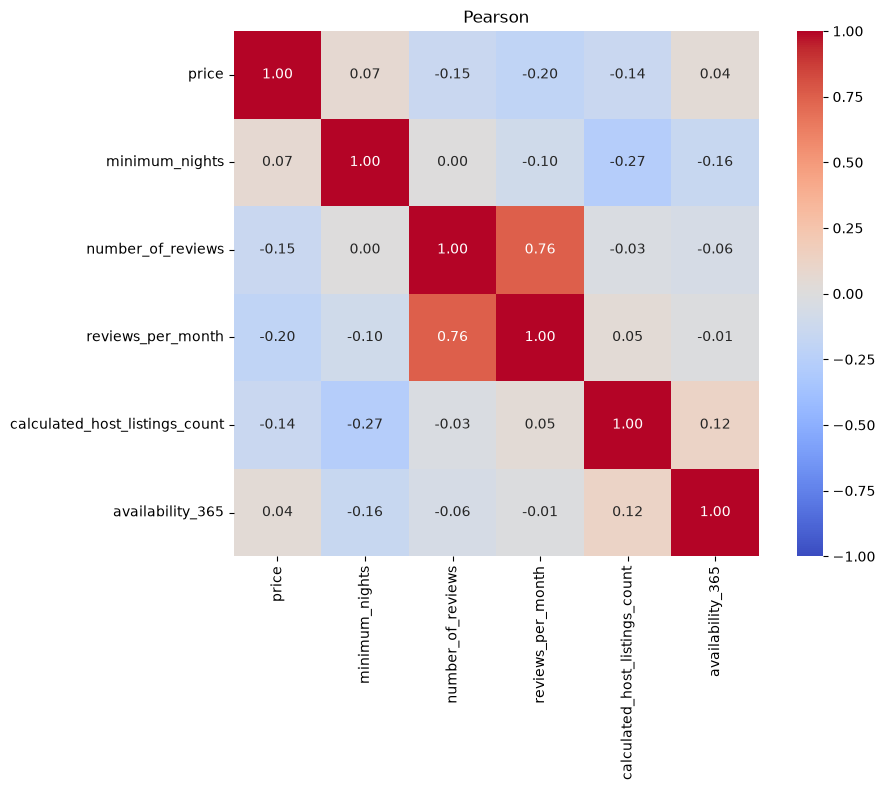

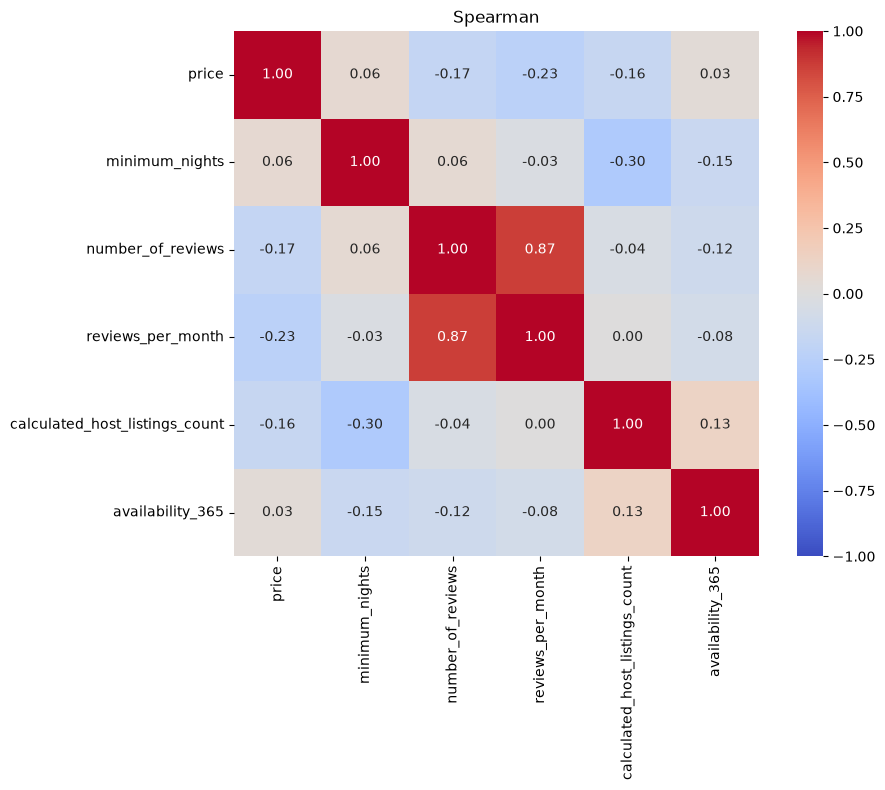

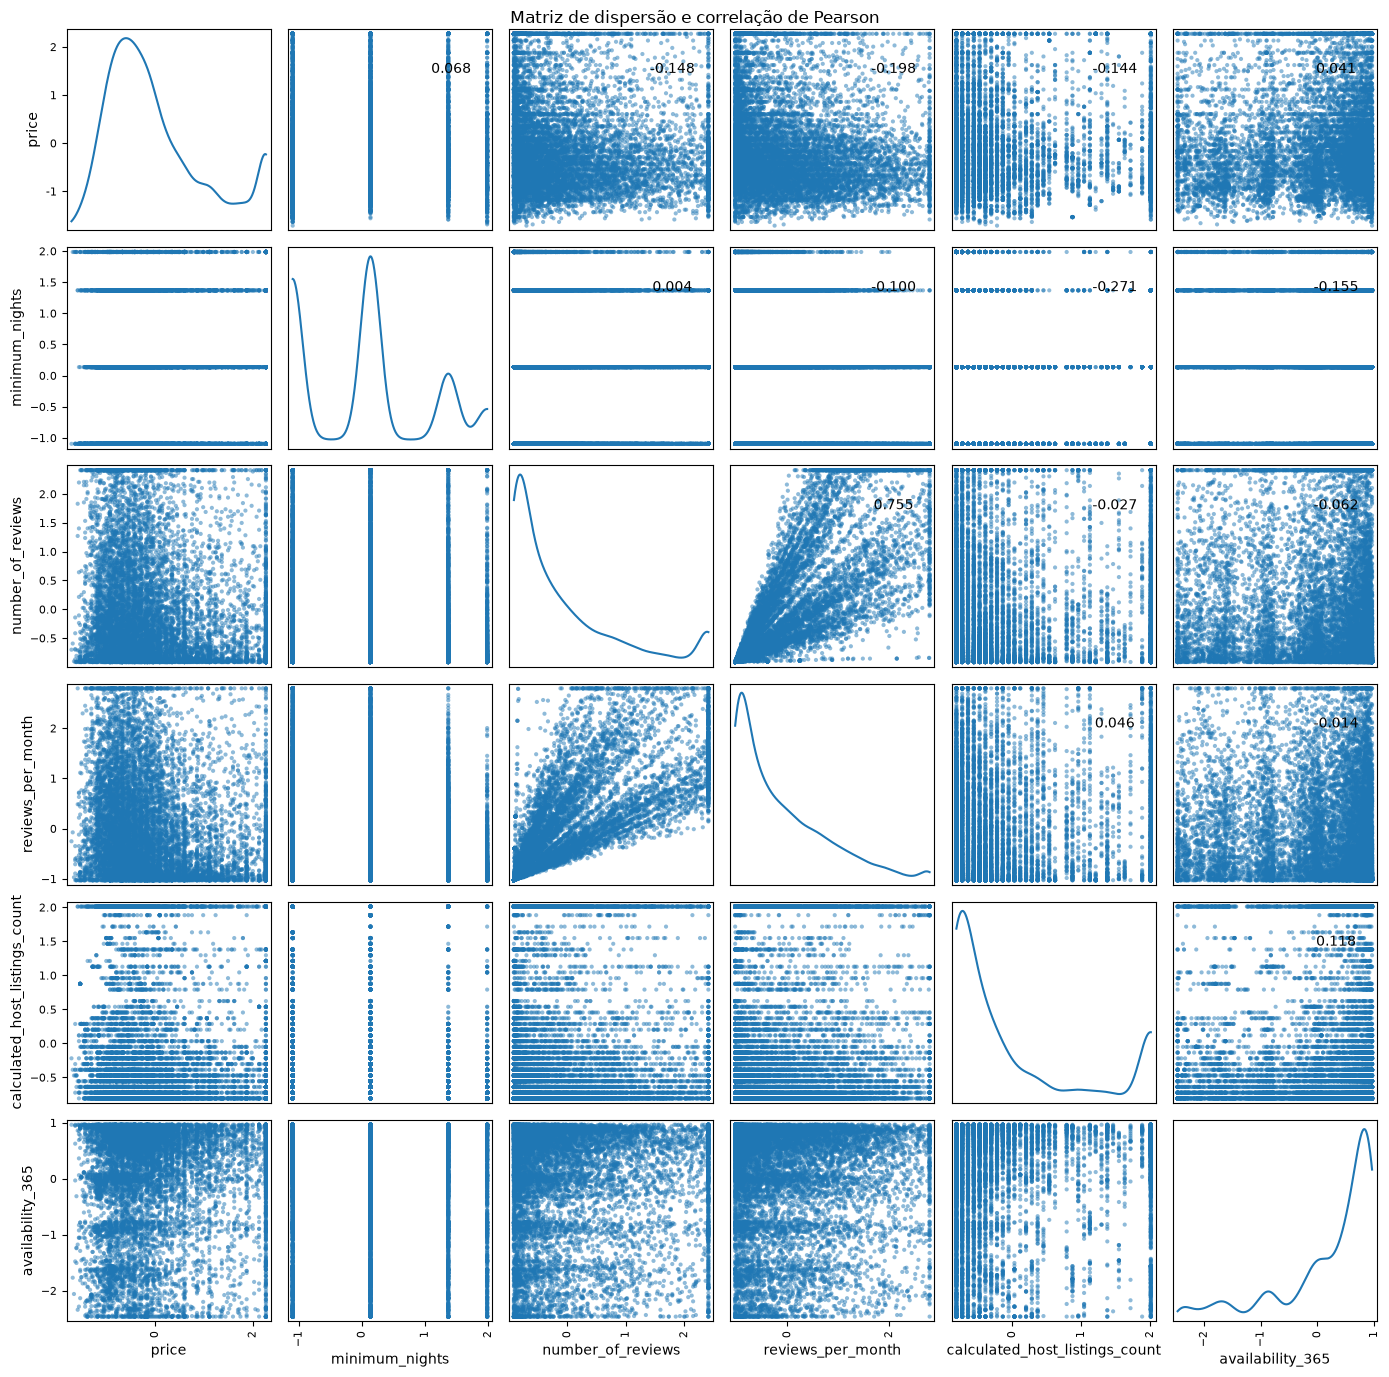

Foi constatada uma correlação muito forte entre "Quantidade de avaliações" e "Quantidade de avaliações por mês".
Decidimos remover a "Quantidade de avaliações por mês", dado que a maioria dos anúncios tende a ter avaliações recentes.


In [533]:
import seaborn as sns
from pandas.plotting import scatter_matrix

print(f"{open_bold}Análise de correlações{close_bold}\n")

print(f"{open_bold}Numéricas x Numéricas{close_bold}\n")

df9 = df8.copy()

numeric_data = df9[numeric_columns]

pearson = numeric_data.corr(method="pearson")
spearman = numeric_data.corr(method="spearman")


def generate_correlation_matrix(matrix: pd.DataFrame, title: str):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        matrix,
        annot=True,  # mostra os valores
        fmt=".2f",  # duas casas decimais
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


generate_correlation_matrix(pearson, "Pearson")
generate_correlation_matrix(spearman, "Spearman")


axes = scatter_matrix(
    numeric_data,
    diagonal="kde",
    figsize=(14, 14),
)
correlation = numeric_data.corr(method="pearson")
for i, j in zip(*np.triu_indices_from(axes, k=1)):
    axes[i, j].annotate(
        f"{correlation.iloc[i, j]:.3f}",
        (0.8, 0.8),
        xycoords="axes fraction",
        ha="center",
        va="center",
    )
plt.suptitle("Matriz de dispersão e correlação de Pearson")
plt.tight_layout()
plt.show()

print(
    f'Foi constatada uma correlação muito forte entre {open_bold}"Quantidade de avaliações"{close_bold} e {open_bold}"Quantidade de avaliações por mês"{close_bold}.\nDecidimos remover a {open_bold}"Quantidade de avaliações por mês"{close_bold}, dado que a maioria dos anúncios tende a ter avaliações recentes.'
)

df9 = df9.drop(columns=["reviews_per_month"])

In [535]:
from itertools import combinations

from scipy.stats import chi2_contingency

print(f"{open_bold}Categóricas x Categóricas{close_bold}\n")

print(
    f'As variáveis {open_bold}"Município do imóvel"{close_bold} e {open_bold}"Freguesia do imóvel"{close_bold} são inerentemente relacionadas hierarquicamente.\nDecidimos remover o {open_bold}"Município do imóvel"{close_bold} por ser de granularidade mais grossa.'
)

df9 = df9.drop(columns=["neighbourhood_group"])

categorical_columns = [
    "neighbourhood",
    "room_type",
    "license",
    "last_review",
]

categorical_data = df8[categorical_columns]


def chi_square_test(
    data_frame: pd.DataFrame,
    column_1: str,
    column_2: str,
    alpha: float = 0.05,
):
    contingency_table = pd.crosstab(
        data_frame[column_1],
        data_frame[column_2],
    )

    stat, p, dof, expected = chi2_contingency(contingency_table)

    print(f"\n{open_bold}{column_1} × {column_2}{close_bold}")

    print("\nMatriz de valores observados:")
    display(contingency_table)

    print(f"\nChi-quadrado: {stat:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Graus de liberdade: {dof}")

    print("\nMatriz de valores esperados:")
    display(
        pd.DataFrame(
            expected,
            index=contingency_table.index,
            columns=contingency_table.columns,
        )
    )

    if p <= alpha:
        print("\nVariáveis dependentes (rejeita-se H0)")
    else:
        print("\nVariáveis independentes (não rejeita-se H0)")


chi_square_test(
    df8,
    "room_type",
    "license",
)

Categóricas x Categóricas

As variáveis "Município do imóvel" e "Freguesia do imóvel" são inerentemente relacionadas hierarquicamente.
Decidimos remover o "Município do imóvel" por ser de granularidade mais grossa.

room_type × license

Matriz de valores observados:


license,al,exempt,no_license,others,ter
room_type,,,,,
Entire home/apt,8128,349,285,55,19
Hotel room,46,0,3,4,0
Private room,1139,159,86,15,2
Shared room,102,4,5,4,0



Chi-quadrado: 230.5775
p-value: 0.000000
Graus de liberdade: 12

Matriz de valores esperados:


license,al,exempt,no_license,others,ter
room_type,,,,,
Entire home/apt,7995.284959,434.794041,321.849495,66.238155,17.833349
Hotel room,47.957232,2.607977,1.930514,0.397309,0.106968
Private room,1267.699664,68.939164,51.031139,10.502451,2.827583
Shared room,104.058145,5.658818,4.188852,0.862086,0.232100



Variáveis dependentes (rejeita-se H0)
